# Auto-Crop Custom-50 — Two Photos, 4 Styles Each (Column Layout)

Each photo has 4 columns of 7 words. Columns = styles, left to right.

**Workflow:**
1. Run cells 1–3: detect + preview groups for each photo
2. Cell 4: fill `PHOTO_STYLE_MAP` — map (photo, column_index) → style name
3. Cell 5: saves crops to `custom_50/<STYLE>/`

In [2]:
!pip install -q opencv-python-headless pillow matplotlib numpy scikit-learn

In [3]:
import os, cv2, numpy as np, glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans

RAW_DIR    = 'raw_photos'
OUTPUT_DIR = 'dataset/custom_50'
CATEGORIES = ['CLEAN', 'SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH']
N_COLS     = 4   # columns per photo

for cat in CATEGORIES:
    os.makedirs(os.path.join(OUTPUT_DIR, cat), exist_ok=True)

photos = sorted(glob.glob(os.path.join(RAW_DIR, '*.jpg')) +
                glob.glob(os.path.join(RAW_DIR, '*.jpeg')) +
                glob.glob(os.path.join(RAW_DIR, '*.png')))
print(f'Photos found: {[os.path.basename(p) for p in photos]}')

Photos found: ['crossout1.png', 'crossout2.png']


In [4]:
def whiten_background(img_gray, sigma=50):
    """Normalize image so the background becomes white (255)."""
    bg   = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=sigma)
    norm = img_gray.astype(np.float32) / (bg.astype(np.float32) + 1e-6)
    return np.clip(norm * 255, 0, 255).astype(np.uint8)


def detect_crops_grid(image_path, n_cols=4, n_rows=7, bottom_crop_frac=0.05, padding=6):
    """
    Projection-based word detection.
    1. Whitens background (handles gray/shaded paper).
    2. Finds column boundaries within actual ink X-extent.
    3. Within each column, finds row boundaries within actual ink Y-extent.
    """
    img_bgr  = cv2.imread(image_path)
    h, w     = img_bgr.shape[:2]
    cut      = int(h * (1 - bottom_crop_frac))
    img_bgr  = img_bgr[:cut]; h = cut
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    img_white = whiten_background(img_gray)
    blurred   = cv2.GaussianBlur(img_white, (3, 3), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    col_proj = binary.sum(axis=0).astype(float)
    col_proj = np.convolve(col_proj, np.ones(15)/15, mode='same')

    def find_valleys(proj, n):
        seg = len(proj) // (n + 1)
        valleys = []
        for i in range(1, n + 1):
            lo = max(0, i*seg - seg//2)
            hi = min(len(proj), i*seg + seg//2)
            valleys.append(lo + np.argmin(proj[lo:hi]))
        return sorted(valleys)

    xs_ink  = np.where(col_proj > col_proj.max() * 0.05)[0]
    x_s = max(0, xs_ink.min() - 20) if len(xs_ink) else 0
    x_e = min(w, xs_ink.max() + 20) if len(xs_ink) else w
    col_splits = [x_s] + [x_s + v for v in find_valleys(col_proj[x_s:x_e], n_cols-1)] + [x_e]

    boxes, crops, col_ids = [], [], []
    for col_idx in range(n_cols):
        x_lo, x_hi = col_splits[col_idx], col_splits[col_idx + 1]
        strip = binary[:, x_lo:x_hi]
        ys_ink = np.where(strip.sum(axis=1) > 0)[0]
        if len(ys_ink) == 0: continue
        y_s = max(0, ys_ink.min() - 10)
        y_e = min(h, ys_ink.max() + 10)
        rp  = strip[y_s:y_e].sum(axis=1).astype(float)
        rp  = np.convolve(rp, np.ones(9)/9, mode='same')
        ls  = [0] + find_valleys(rp, n_rows - 1) + [len(rp)]
        row_splits = [y_s + s for s in ls]
        for row_idx in range(n_rows):
            y_lo, y_hi = row_splits[row_idx], row_splits[row_idx + 1]
            cell = binary[y_lo:y_hi, x_lo:x_hi]
            ys, xs = np.where(cell > 0)
            if len(xs) == 0: continue
            x1=max(x_lo,x_lo+xs.min()-padding); x2=min(w,x_lo+xs.max()+padding+1)
            y1=max(0,y_lo+ys.min()-padding);     y2=min(h,y_lo+ys.max()+padding+1)
            boxes.append((x1, y1, x2-x1, y2-y1))
            crops.append(Image.fromarray(img_white[y1:y2, x1:x2]))
            col_ids.append(col_idx)

    return img_bgr, boxes, crops, col_ids


print('detect_crops_grid() defined.')


=== crossout1.png: 28 crops, 4 columns ===
  Col 0: 7 crops
  Col 1: 7 crops
  Col 2: 7 crops
  Col 3: 7 crops


/var/folders/34/gp_zqq8s68l08cbyqd89g9x80000gn/T/ipykernel_89214/2387812640.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', N_COLS)


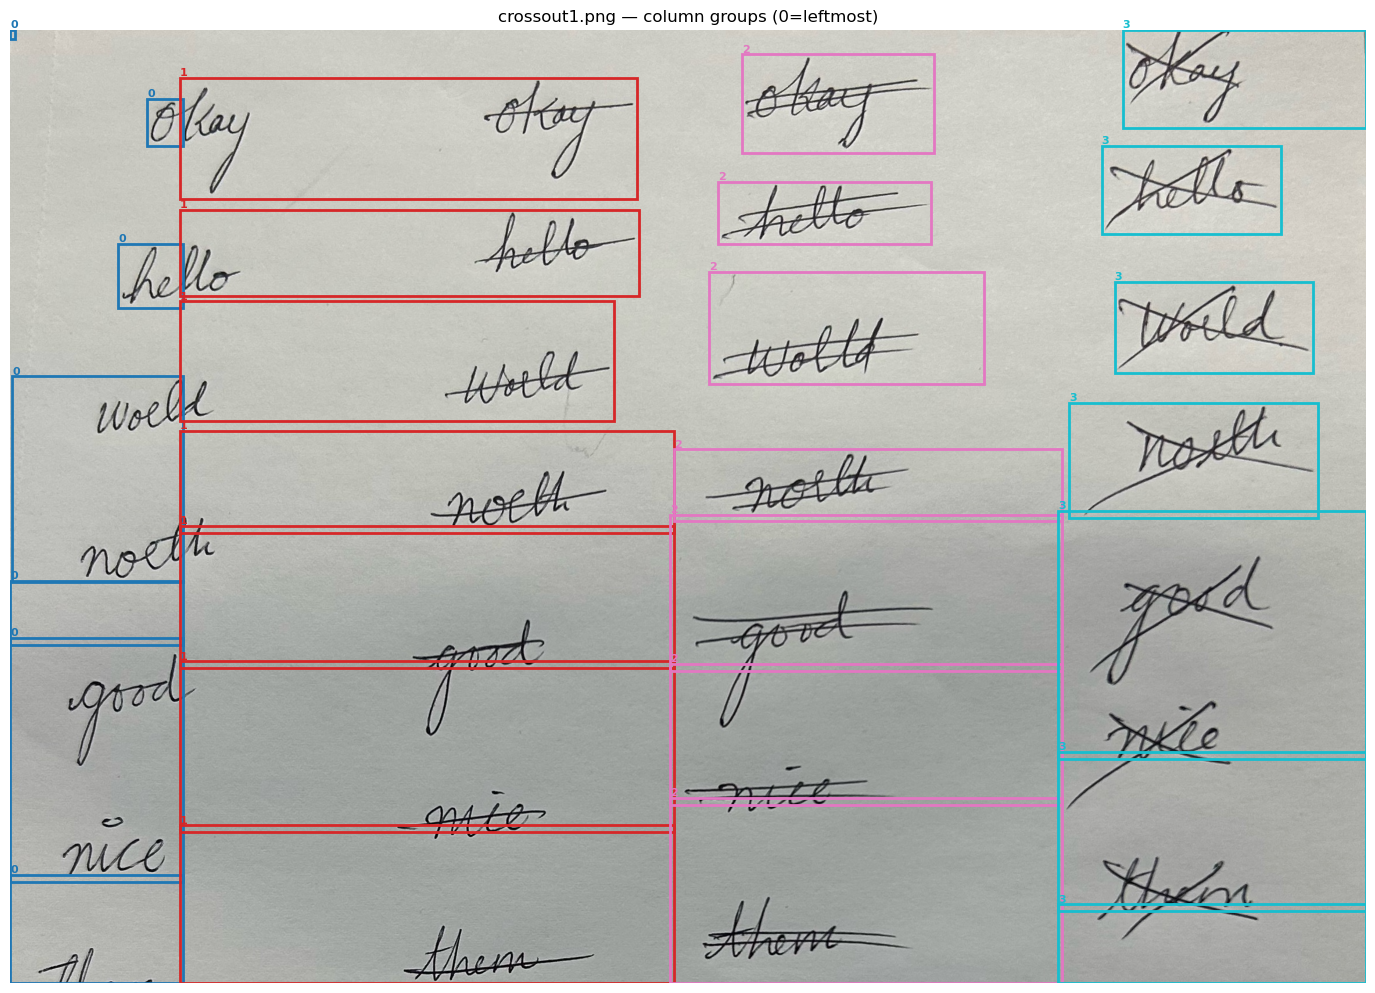

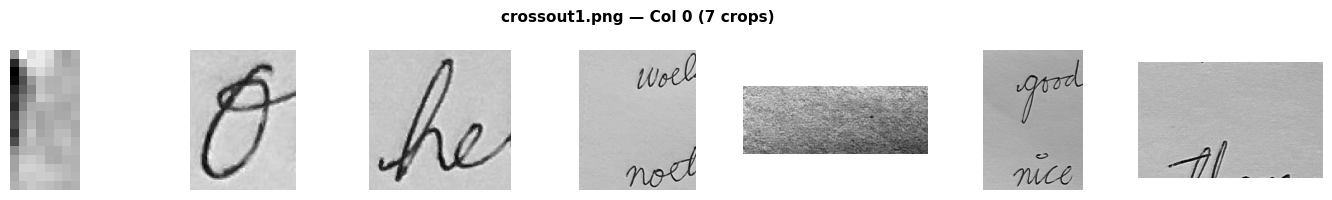

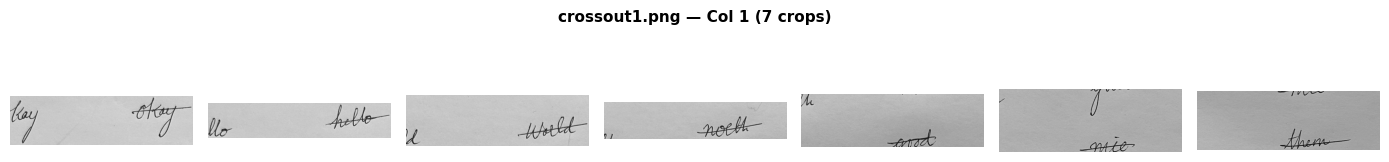

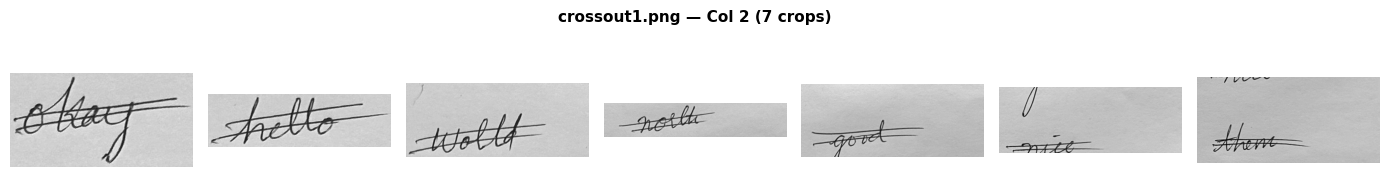

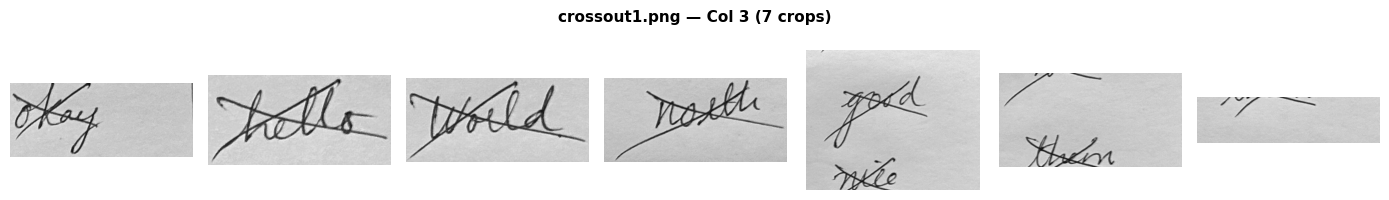


=== crossout2.png: 28 crops, 4 columns ===
  Col 0: 7 crops
  Col 1: 7 crops
  Col 2: 7 crops
  Col 3: 7 crops


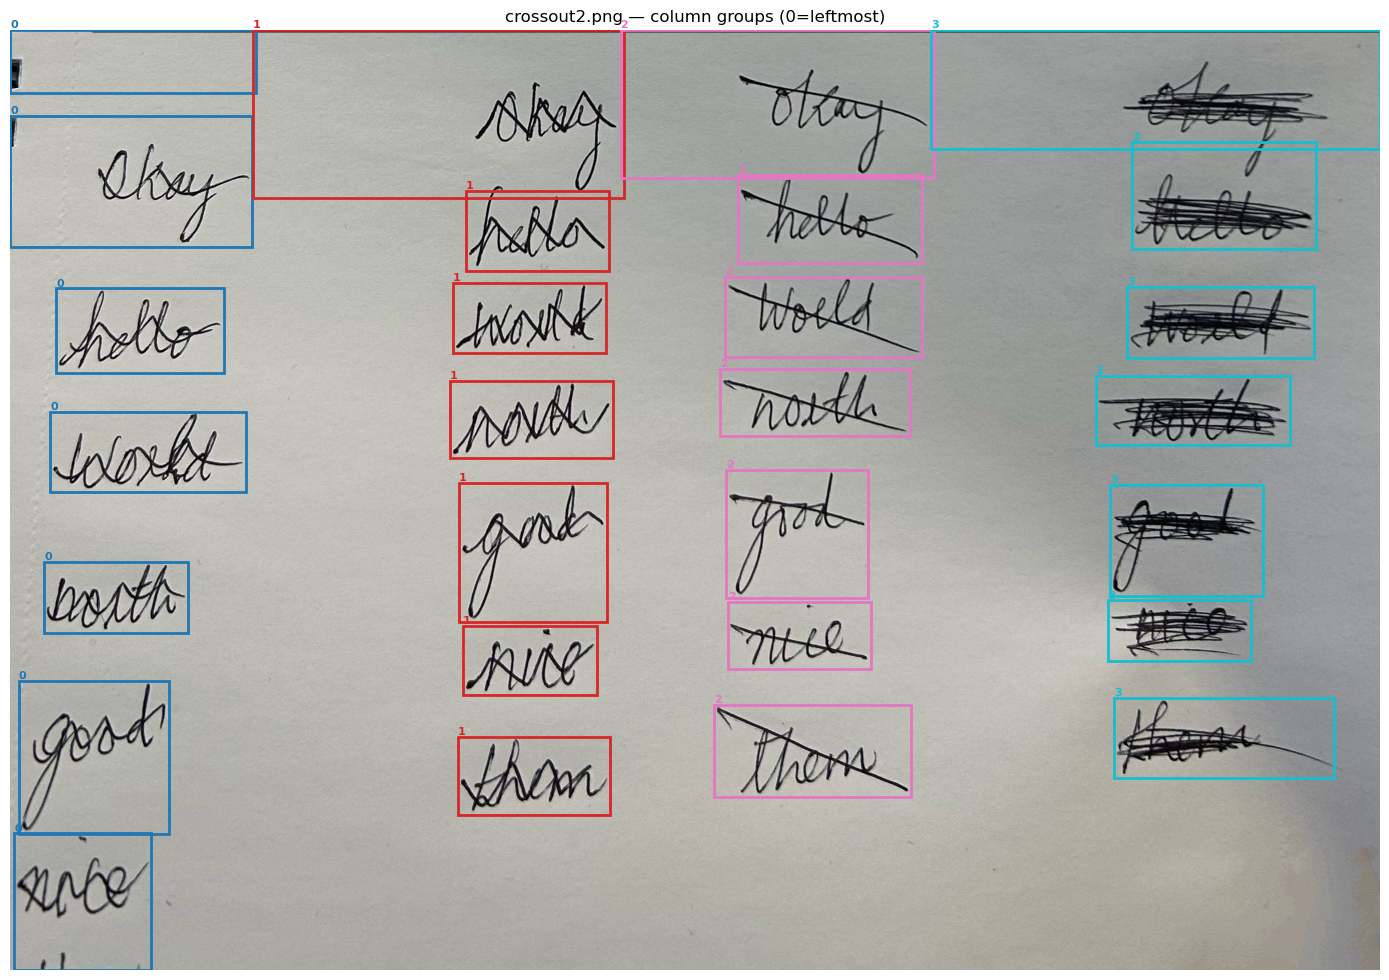

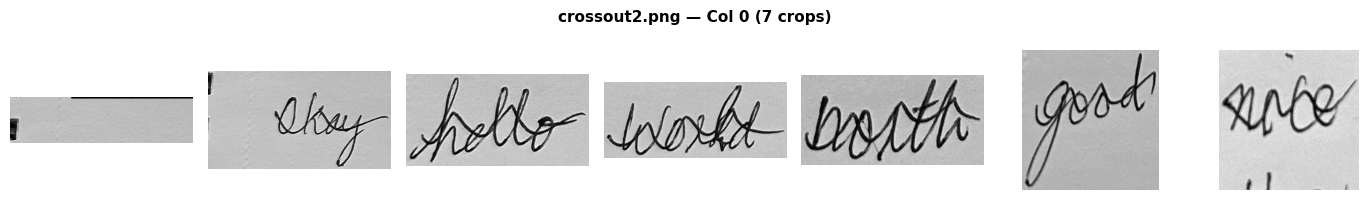

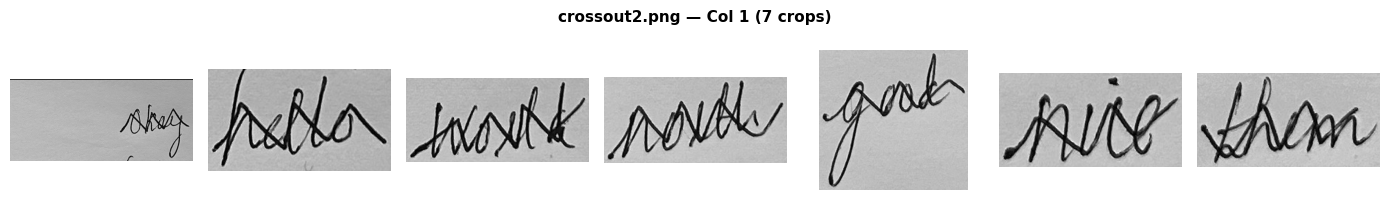

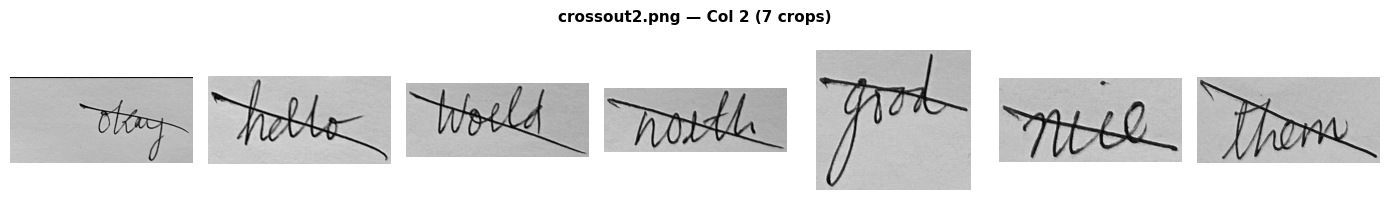

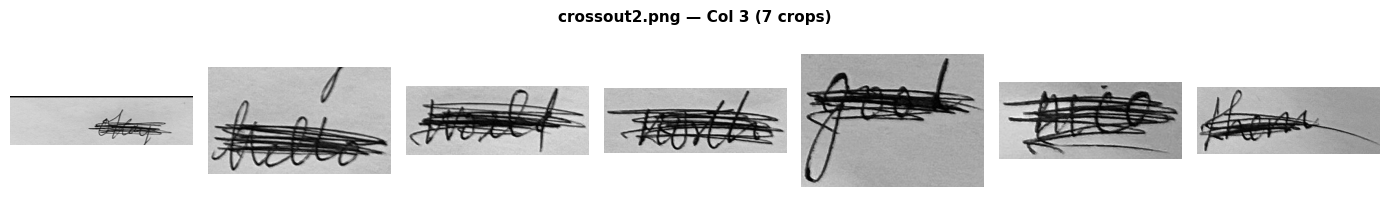

In [5]:
all_data = {}

for photo_path in photos:
    name = os.path.basename(photo_path)
    img_bgr, boxes, crops, col_ids = detect_crops_grid(photo_path, n_cols=N_COLS, n_rows=7)
    all_data[name] = (img_bgr, boxes, crops, col_ids)

    print(f'\n=== {name}: {len(boxes)} crops, {len(set(col_ids))} columns ===')
    for c in sorted(set(col_ids)):
        cnt = sum(1 for x in col_ids if x == c)
        print(f'  Col {c}: {cnt} crops')

    # Annotated overview
    colors = plt.cm.get_cmap('tab10', N_COLS)
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    for i, (bx, by, bw, bh) in enumerate(boxes):
        c = colors(col_ids[i])
        rect = patches.Rectangle((bx, by), bw, bh, linewidth=2,
                                   edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ax.text(bx, by-4, str(col_ids[i]), color=c, fontsize=8, fontweight='bold')
    ax.set_title(f'{name} — column groups (0=leftmost)')
    ax.axis('off')
    plt.tight_layout(); plt.show()

    for c in sorted(set(col_ids)):
        g_crops = [crops[i] for i, cid in enumerate(col_ids) if cid == c]
        n = len(g_crops)
        fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
        if n == 1: axes = [axes]
        for ax, crop in zip(axes, g_crops):
            ax.imshow(crop, cmap='gray'); ax.axis('off')
        fig.suptitle(f'{name} — Col {c} ({n} crops)', fontsize=11, fontweight='bold')
        plt.tight_layout(); plt.show()

In [6]:
# ── FILL IN after checking previews above ───────────────────────────────────
PHOTO_STYLE_MAP = {
    ('crossout1.png', 0): 'CLEAN',
    ('crossout1.png', 1): 'SINGLE_LINE',
    ('crossout1.png', 2): 'DOUBLE_LINE',
    ('crossout1.png', 3): 'CROSS',
    ('crossout2.png', 0): 'WAVE',
    ('crossout2.png', 1): 'ZIG_ZAG',
    ('crossout2.png', 2): 'DIAGONAL',
    ('crossout2.png', 3): 'SCRATCH',
}

for (photo, col), style in PHOTO_STYLE_MAP.items():
    if style not in CATEGORIES:
        print(f'WARNING: "{style}" not in CATEGORIES')
print('Mapping looks valid.')

Mapping looks valid.


In [7]:
import glob as _glob

# Clear existing images in each category folder
for style in CATEGORIES:
    folder = os.path.join(OUTPUT_DIR, style)
    for f in _glob.glob(os.path.join(folder, '*.png')) + _glob.glob(os.path.join(folder, '*.jpg')):
        os.remove(f)

# Save crops
total_saved = 0
for photo_name, col_style_list in [
    ('crossout1.png', [(0,'CLEAN'),(1,'SINGLE_LINE'),(2,'DOUBLE_LINE'),(3,'CROSS')]),
    ('crossout2.png', [(0,'WAVE'),(1,'ZIG_ZAG'),(2,'DIAGONAL'),(3,'SCRATCH')]),
]:
    photo_path = os.path.join(RAW_DIR, photo_name)
    if photo_name not in all_data:
        print(f'Not loaded: {photo_name}'); continue
    _, _, crops, col_ids = all_data[photo_name]
    for col_idx, style in col_style_list:
        folder  = os.path.join(OUTPUT_DIR, style)
        g_crops = [crops[i] for i,c in enumerate(col_ids) if c==col_idx]
        for idx, crop in enumerate(g_crops):
            crop.save(os.path.join(folder, f'{style.lower()}_{idx:02d}.png'))
            total_saved += 1
        print(f'  {style:<15} {len(g_crops):>3} crops saved')

print(f'\nTotal: {total_saved} images saved')

In [8]:
# Distribution check
print(f'{"Category":<15} {"Count":>5}')
print('-' * 22)
total = 0
for cat in CATEGORIES:
    folder = os.path.join(OUTPUT_DIR, cat)
    n = len([f for f in os.listdir(folder) if f.endswith('.png')]) if os.path.exists(folder) else 0
    total += n
    flag = '' if n == 7 else f'  ← {n} (expected 7)'
    print(f'  {cat:<15} {n:>5}{flag}')
print(f'\nTotal: {total}/56')
print('Ready for evaluation' if total >= 50 else 'WARNING: too few images')